In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.11/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [ ]:
!pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Lectura de datos

In [4]:
df = pd.read_excel('/home/debian12/Documentos/UD/Mineria_de_Datos-1/Tareas/Quiz MD/Datos1D.xlsx')
df.head()

,ingresos,consumo
0,44.617090,9.720475
1,73.430827,12.340257
2,5.010866,1.535624
3,33.721594,7.879812
4,18.941810,4.721109


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ingresos  1000 non-null   float64
 1   consumo   1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [160]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ingresos,1000.0,52.557437,27.407560,5.010866,28.933787,53.212577,76.313770,99.745671
consumo,1000.0,9.282316,3.218789,1.419883,7.055647,10.781619,11.838378,12.482348


In [161]:
df.shape

(1000, 2)

Las dimensines que tiene el fichero son 1000 registros y 2 series.

Las variables que contiene son los ingresos y el consumo.

## Modelo polinomial

In [162]:
from sklearn.preprocessing import PolynomialFeatures

# Separamos variables
X = df.iloc[:, 0].values.reshape(-1, 1)  # columna de entrada
y = df.iloc[:, 1].values                 # columna de salida

# Construcción de características polinomiales hasta grado 7
poly = PolynomialFeatures(degree=7, include_bias=True)
X_poly = poly.fit_transform(X)

print("Forma de X_poly:", X_poly.shape)


Forma de X_poly: (1000, 8)


In [163]:
print("Matriz x:", X_poly)
print("--------------------------------------------------------------")
print("Ejemplo de fila:", X_poly[0])

Matriz x: [[1.00000000e+00 4.46170904e+01 1.99068476e+03 ... 1.76809758e+08
  7.88873695e+09 3.51972490e+11]
 [1.00000000e+00 7.34308269e+01 5.39208634e+03 ... 2.13497156e+09
  1.56772727e+11 1.15119510e+13]
 [1.00000000e+00 5.01086561e+00 2.51087741e+01 ... 3.15910292e+03
  1.58298402e+04 7.93212017e+04]
 ...
 [1.00000000e+00 6.85356776e+01 4.69713910e+03 ... 1.51211058e+09
  1.03633523e+11 7.10259375e+12]
 [1.00000000e+00 3.59668847e+01 1.29361679e+03 ... 6.01885822e+07
  2.16479580e+09 7.78609608e+10]
 [1.00000000e+00 7.85753403e+01 6.17408410e+03 ... 2.99523810e+09
  2.35351853e+11 1.84928520e+13]]
--------------------------------------------------------------
Ejemplo de fila: [1.00000000e+00 4.46170904e+01 1.99068476e+03 8.88185620e+04
 3.96282581e+06 1.76809758e+08 7.88873695e+09 3.51972490e+11]


## Ecuación normal

In [164]:
# Tomamos solo los primeros 10 datos para entrenamiento
X_train = X_poly[:10]
y_train = y[:10]

# Ecuación normal sin regularización (λ=0)
w = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
print("Coeficientes w*:", w)


Coeficientes w*: [-3.08029387e+00  1.70154086e+00 -2.22243033e-01  1.60429436e-02
 -6.09940122e-04  1.24712477e-05 -1.29448014e-07  5.33238945e-10]


## Función de coste

In [165]:
# Dividimos datos: 10 train, 990 test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=10, shuffle=True, random_state=42)

def costo(X, y, w):
    y_pred = X @ w
    return np.mean((y_pred - y) ** 2)

cost_train = []
cost_test = []

for r in range(1, 8):
    # Construcción de características polinomiales
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X_train)
    X_test_r = poly_r.transform(X_test)

    # Ecuación normal (sin regularización)
    w_r = np.linalg.inv(X_train_r.T @ X_train_r) @ X_train_r.T @ y_train

    # Cálculo de costos
    cost_train.append(costo(X_train_r, y_train, w_r))
    cost_test.append(costo(X_test_r, y_test, w_r))


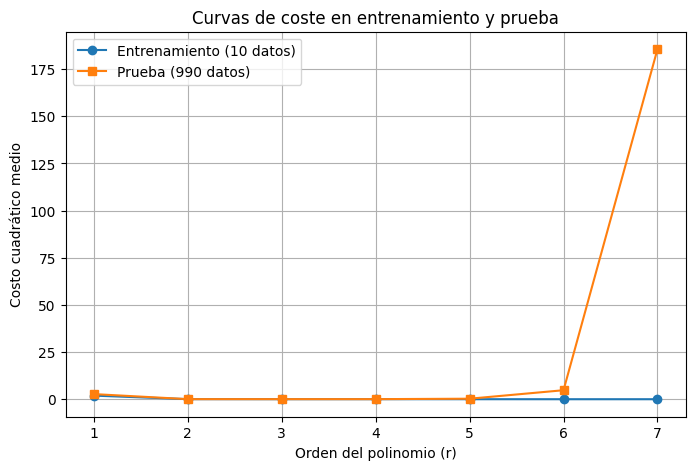

In [ ]:
# Graficamos
plt.figure(figsize=(8,5))
plt.plot(range(1, ), cost_train, marker="o", label="Entrenamiento (10 datos)")
plt.plot(range(1, 8), cost_test, marker="s", label="Prueba (990 datos)")
plt.xlabel("Orden del polinomio (r)")
plt.ylabel("Costo cuadrático medio")
plt.title("Curvas de coste en entrenamiento y prueba")
plt.legend()
plt.grid(True)
plt.show()



## Selección de hiperparámetros

In [ ]:
# División de datos: 10 train, 490 val, 500 test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=10, shuffle=True, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=490, shuffle=True, random_state=42)

lambdas = np.logspace(-4, 4, 20)

# --------------------------
# Mejor ajuste global (un r y λ)
# --------------------------
best_r, best_lambda, best_cost, best_model, best_poly = None, None, float("inf"), None, None

for r in range(1, 8):
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X_train)
    X_val_r = poly_r.transform(X_val)

    for l in lambdas:
        ridge = Ridge(alpha=l, fit_intercept=False)
        ridge.fit(X_train_r, y_train)
        y_val_pred = ridge.predict(X_val_r)
        cost_val = np.mean((y_val - y_val_pred) ** 2)

        if cost_val < best_cost:
            best_cost = cost_val
            best_r = r
            best_lambda = l
            best_model = ridge
            best_poly = poly_r

In [168]:
print("👉 Mejor combinación encontrada (global):")
print(f" - Grado polinomial r = {best_r}")
print(f" - λ = {best_lambda}")
print(f" - Costo en validación = {best_cost}")

👉 Mejor combinación encontrada (global):
 - Grado polinomial r = 4
 - λ = 11.288378916846883
 - Costo en validación = 0.03534127149433126


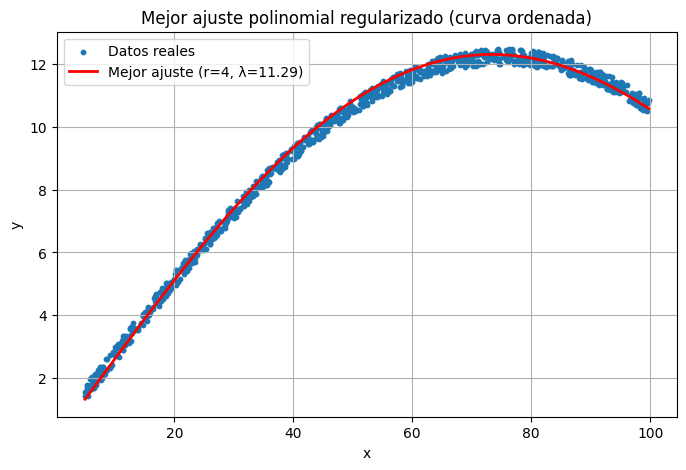

In [169]:
# Ordenamos los datos para graficar suavemente
X_sorted = np.sort(X, axis=0)
X_sorted_poly = best_poly.transform(X_sorted)
y_sorted_pred = best_model.predict(X_sorted_poly)

plt.figure(figsize=(8,5))
plt.scatter(X, y, s=10, label="Datos reales")
plt.plot(X_sorted, y_sorted_pred, color="red", linewidth=2,
         label=f"Mejor ajuste (r={best_r}, λ={best_lambda:.2f})")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mejor ajuste polinomial regularizado (curva ordenada)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# --------------------------
# Mejor ajuste para cada r
# --------------------------
best_models = {}

for r in range(1, 8):
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X_train)
    X_val_r = poly_r.transform(X_val)

    best_lambda, best_cost, best_model = None, float("inf"), None

    for l in lambdas:
        ridge = Ridge(alpha=l, fit_intercept=False)
        ridge.fit(X_train_r, y_train)
        y_val_pred = ridge.predict(X_val_r)
        cost_val = np.mean((y_val - y_val_pred) ** 2)

        if cost_val < best_cost:
            best_cost = cost_val
            best_lambda = l
            best_model = ridge

    best_models[r] = (best_lambda, best_cost, best_model, poly_r)

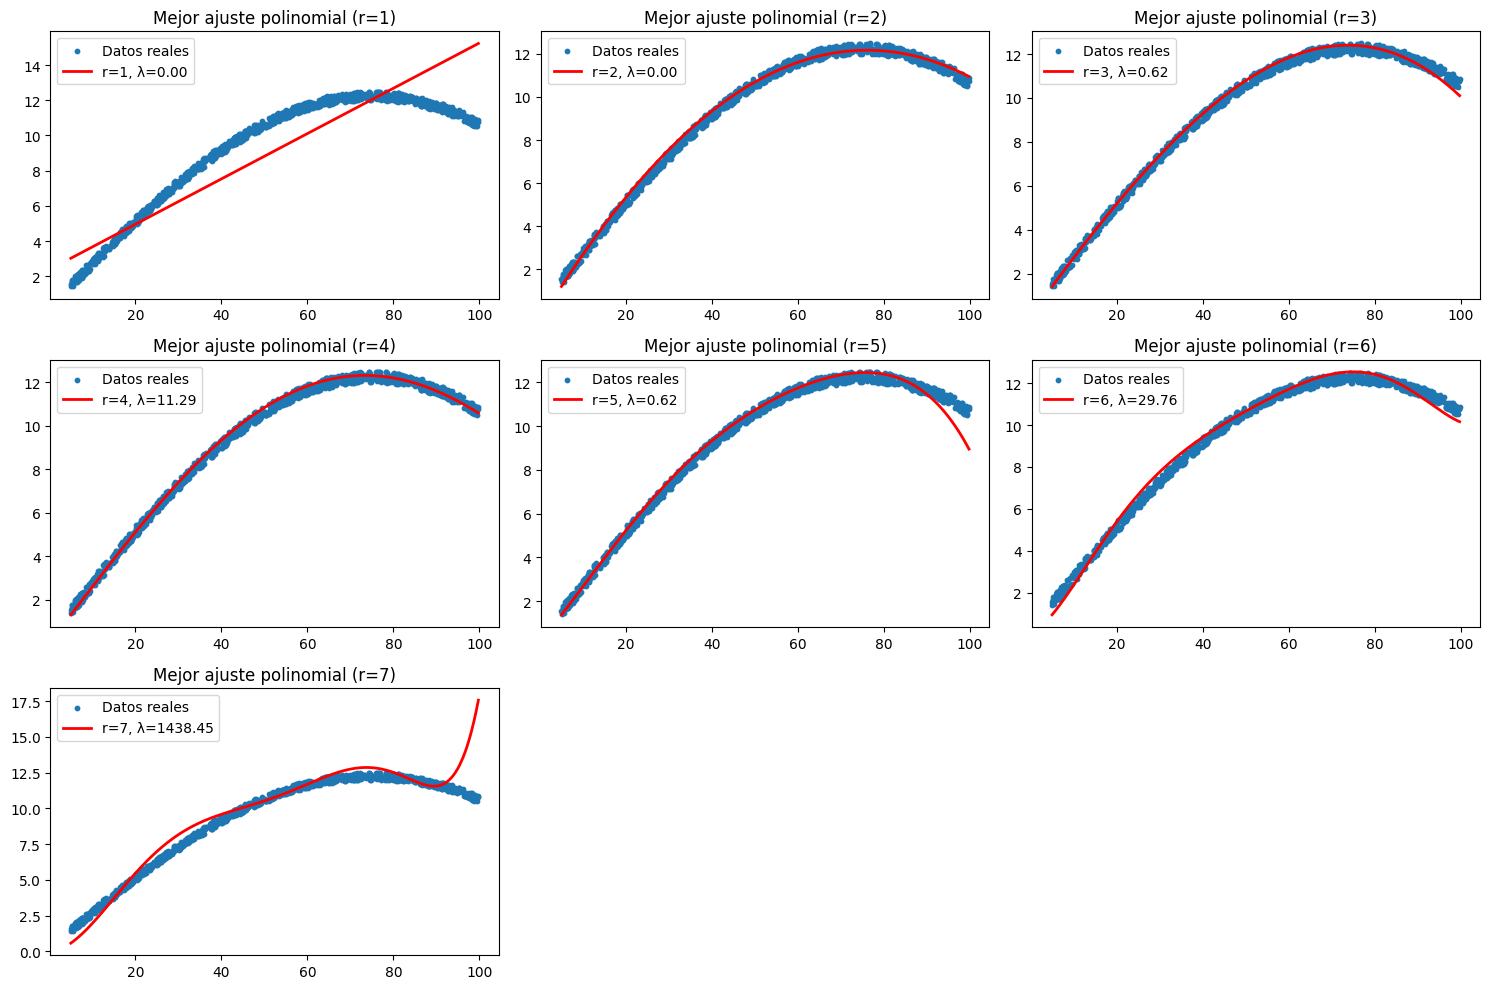

In [171]:
# --------------------------
# Gráficas: mejor ajuste por cada r
# --------------------------
plt.figure(figsize=(15, 10))
X_sorted = np.sort(X, axis=0)

for i, r in enumerate(range(1, 8), 1):
    best_lambda, best_cost, best_model, best_poly = best_models[r]
    X_sorted_poly = best_poly.transform(X_sorted)
    y_sorted_pred = best_model.predict(X_sorted_poly)

    plt.subplot(3, 3, i)
    plt.scatter(X, y, s=10, label="Datos reales")
    plt.plot(X_sorted, y_sorted_pred, color="red", linewidth=2,
             label=f"r={r}, λ={best_lambda:.2f}")
    plt.title(f"Mejor ajuste polinomial (r={r})")
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Guardamos los costos de validación para cada r
val_costs_per_r = {}

for r in range(1, 8):
    poly_r = PolynomialFeatures(degree=r, include_bias=True)
    X_train_r = poly_r.fit_transform(X_train)
    X_val_r = poly_r.transform(X_val)
    costs_lambda = []
    for l in lambdas:
        model = Ridge(alpha=l, fit_intercept=False)
        model.fit(X_train_r, y_train)
        y_val_pred = model.predict(X_val_r)
        cost_val = np.mean((y_val - y_val_pred) ** 2)
        costs_lambda.append(cost_val)
    val_costs_per_r[r] = costs_lambda

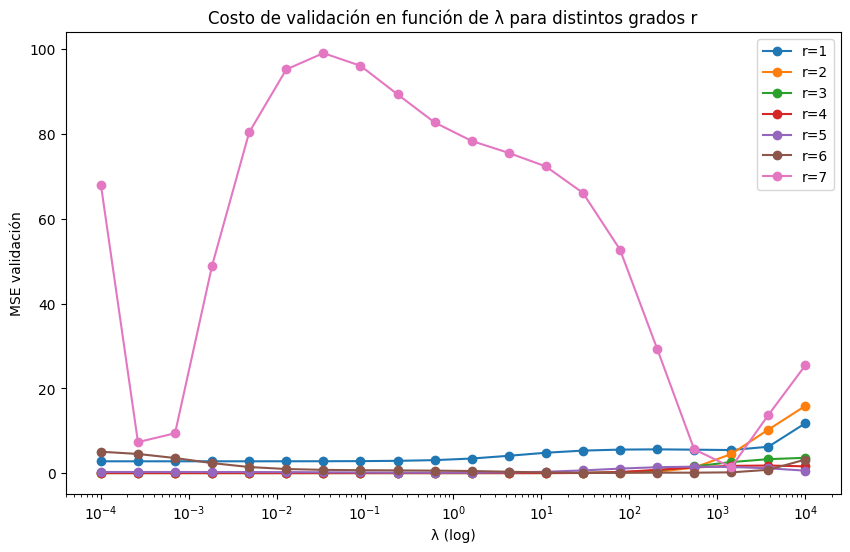

In [173]:
# Graficamos
plt.figure(figsize=(10, 6))
for r in range(1, 8):
    plt.semilogx(lambdas, val_costs_per_r[r], marker='o', label=f"r={r}")

plt.xlabel("λ (log)")
plt.ylabel("MSE validación")
plt.title("Costo de validación en función de λ para distintos grados r")
plt.legend()
plt.show()